# Adding roads to the graph

In [1]:
import geopandas as gpd

import os
os.getcwd()

import pickle

## Initialization

In [2]:
local_crs = 32637 # Tula region crs 

The graph can be obtained by ``transport_frames.graph.get_graph()``

In [3]:
with open("data/G_drive.pickle", "rb") as f:
    G_drive = pickle.load(f)

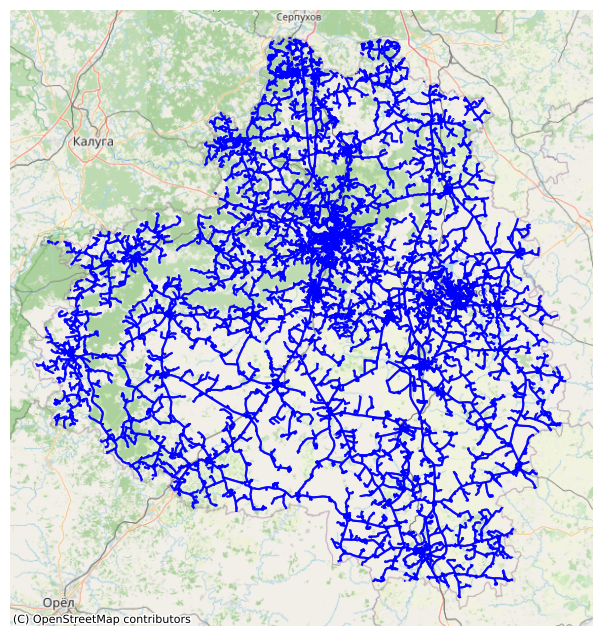

In [4]:
from transport_frames.utils.helper_funcs import plot_graph

plot_graph(G_drive)

Load a file with the roads to add. They must contain ``ref_type`` and ``reg`` parameter 

In [5]:
new_roads = gpd.read_file("data/new_road_tula_region.geojson")
new_roads

,maxspeed,highway,ref,reg,node_start,node_end,geometry
0,1000.0,None,None,1,None,None,"LINESTRING (390444.88 6012584.465, 390410.011 ..."


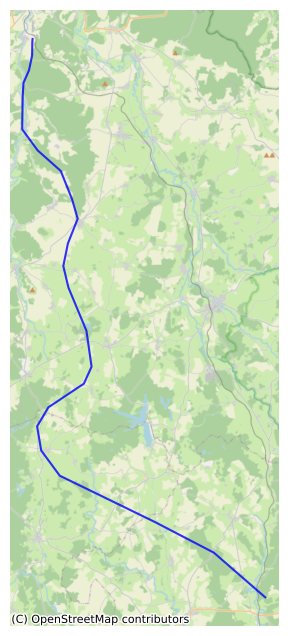

In [6]:
plot_graph(edges = new_roads)

## Road addition

In [7]:
from transport_frames.road_adder import add_roads

new_road_graph = add_roads(G_drive, new_roads, local_crs)

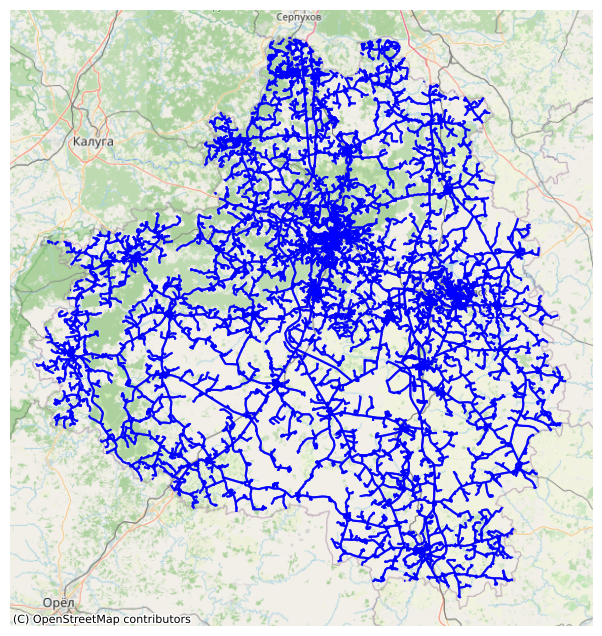

In [8]:
plot_graph(new_road_graph)

## Check connectivity improvement
To see difference in travel time with new roads

In [9]:
settlement_points = gpd.read_file("data/tula_region_towns.geojson")
settlement_polygons = gpd.read_file("data/tula_region_municipalities.geojson")

In [10]:
from transport_frames.indicators import get_connectivity

con_old = get_connectivity(settlement_points,settlement_polygons,local_crs,graph = G_drive)
con_old.head()

2026-04-05 00:26:17.418 | WARNING  | Removing 197 nodes from 22 smaller strongly connected components. These are subgraphs where nodes are internally reachable but isolated from the rest. Retaining only the largest strongly connected component (31927 nodes).


,name,geometry,connectivity
0,Манаенское,"POLYGON ((36.27046 53.67571, 36.27343 53.67505...",145.007980
1,Астаповское,"POLYGON ((36.47061 53.63576, 36.48947 53.63114...",130.750246
2,Арсеньево,"POLYGON ((36.63005 53.72754, 36.63174 53.72702...",118.799943
3,Левобережное,"POLYGON ((35.89856 53.85018, 35.90015 53.84679...",159.656568
4,Правобережное,"POLYGON ((36.1455 53.80533, 36.14561 53.80468,...",153.267224


In [11]:
con_new = get_connectivity(settlement_points,settlement_polygons,local_crs,graph = new_road_graph)
con_new.head()

2026-04-05 00:26:37.405 | WARNING  | Removing 197 nodes from 22 smaller strongly connected components. These are subgraphs where nodes are internally reachable but isolated from the rest. Retaining only the largest strongly connected component (31940 nodes).


,name,geometry,connectivity
0,Манаенское,"POLYGON ((36.27046 53.67571, 36.27343 53.67505...",140.871501
1,Астаповское,"POLYGON ((36.47061 53.63576, 36.48947 53.63114...",126.899580
2,Арсеньево,"POLYGON ((36.63005 53.72754, 36.63174 53.72702...",115.505683
3,Левобережное,"POLYGON ((35.89856 53.85018, 35.90015 53.84679...",156.128797
4,Правобережное,"POLYGON ((36.1455 53.80533, 36.14561 53.80468,...",149.911153


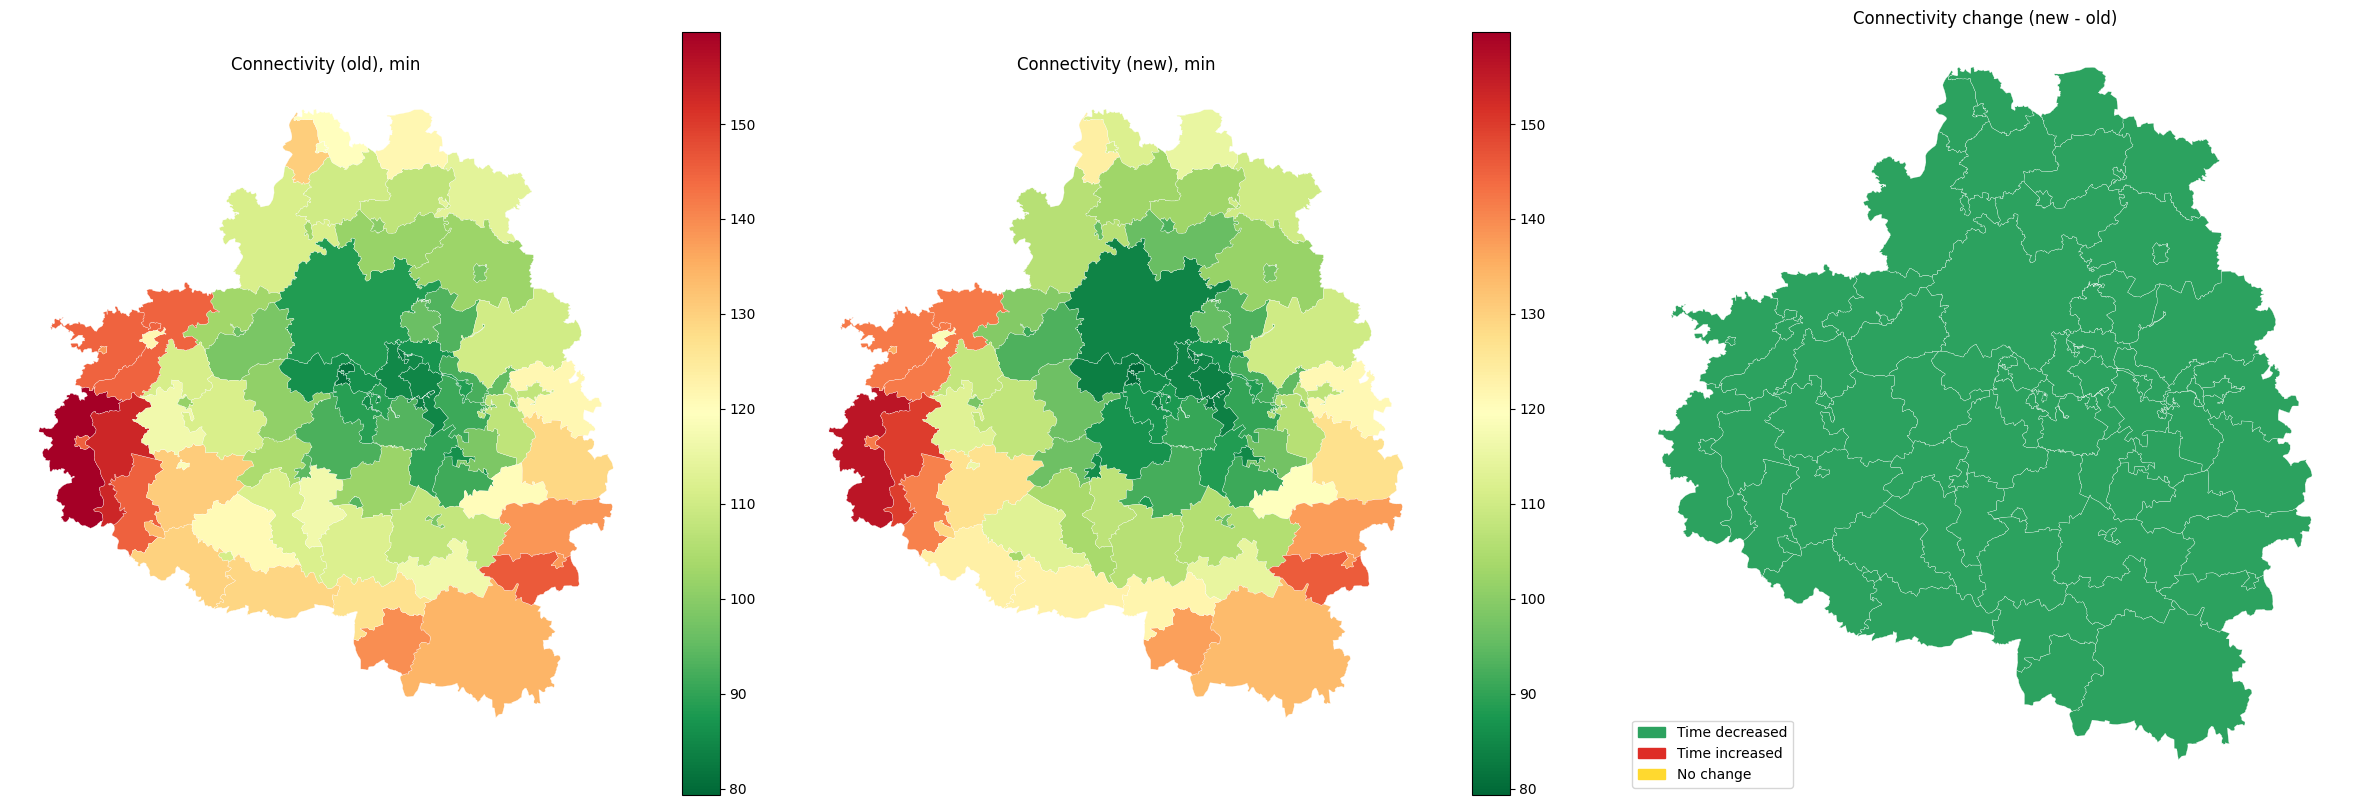

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

cmp = con_old[["geometry", "connectivity"]].rename(
    columns={"connectivity": "connectivity_old"}
).join(
    con_new[["connectivity"]].rename(columns={"connectivity": "connectivity_new"}),
    how="inner",
)


cmp["delta"] = cmp["connectivity_new"] - cmp["connectivity_old"]

eps = 1e-9
cmp["change"] = np.select(
    [cmp["delta"] < -eps, cmp["delta"] > eps],
    ["decreased", "increased"],
    default="unchanged",
)

vmin = min(cmp["connectivity_old"].min(), cmp["connectivity_new"].min())
vmax = max(cmp["connectivity_old"].max(), cmp["connectivity_new"].max())

fig, ax = plt.subplots(1, 3, figsize=(24, 8))

cmp.plot(
    column="connectivity_old",
    cmap="RdYlGn_r",
    legend=True,
    linewidth=0.2,
    edgecolor="white",
    vmin=vmin,
    vmax=vmax,
    ax=ax[0],
    aspect="auto",
)
ax[0].set_title("Connectivity (old), min")
ax[0].set_axis_off()

cmp.plot(
    column="connectivity_new",
    cmap="RdYlGn_r",
    legend=True,
    linewidth=0.2,
    edgecolor="white",
    vmin=vmin,
    vmax=vmax,
    ax=ax[1],
    aspect="auto",
)
ax[1].set_title("Connectivity (new), min")
ax[1].set_axis_off()

color_map = {
    "decreased": "#2ca25f",
    "increased": "#de2d26",
    "unchanged": "#ffd92f",  
}

for cls, color in color_map.items():
    part = cmp[cmp["change"] == cls]
    if part.empty:
        continue
    part.plot(
        color=color,
        linewidth=0.2,
        edgecolor="white",
        ax=ax[2],
        aspect="auto",
    )

ax[2].set_title("Connectivity change (new - old)")
ax[2].set_axis_off()
ax[2].legend(
    handles=[
        mpatches.Patch(color=color_map["decreased"], label="Time decreased"),
        mpatches.Patch(color=color_map["increased"], label="Time increased"),
        mpatches.Patch(color=color_map["unchanged"], label="No change"),
    ],
    loc="lower left",
)

plt.tight_layout()